In [10]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split



In [11]:
ds=pd.read_csv('rideshare_kaggle.csv')
ds.shape


(693071, 57)

In [12]:
ds.describe()

,timestamp,hour,day,month,price,distance,surge_multiplier,latitude,longitude,temperature,...,precipIntensityMax,uvIndexTime,temperatureMin,temperatureMinTime,temperatureMax,temperatureMaxTime,apparentTemperatureMin,apparentTemperatureMinTime,apparentTemperatureMax,apparentTemperatureMaxTime
count,6.930710e+05,693071.000000,693071.000000,693071.000000,637976.000000,693071.000000,693071.000000,693071.000000,693071.000000,693071.000000,...,693071.000000,6.930710e+05,693071.000000,6.930710e+05,693071.000000,6.930710e+05,693071.000000,6.930710e+05,693071.000000,6.930710e+05
mean,1.544046e+09,11.619137,17.794365,11.586684,16.545125,2.189430,1.013870,42.338172,-71.066151,39.584388,...,0.037374,1.544044e+09,33.457774,1.544042e+09,45.261313,1.544047e+09,29.731002,1.544048e+09,41.997343,1.544048e+09
std,6.891925e+05,6.948114,9.982286,0.492429,9.324359,1.138937,0.091641,0.047840,0.020302,6.726084,...,0.055214,6.912028e+05,6.467224,6.901954e+05,5.645046,6.901353e+05,7.110494,6.871862e+05,6.936841,6.910777e+05
min,1.543204e+09,0.000000,1.000000,11.000000,2.500000,0.020000,1.000000,42.214800,-71.105400,18.910000,...,0.000000,1.543162e+09,15.630000,1.543122e+09,33.510000,1.543154e+09,11.810000,1.543136e+09,28.950000,1.543187e+09
25%,1.543444e+09,6.000000,13.000000,11.000000,9.000000,1.280000,1.000000,42.350300,-71.081000,36.450000,...,0.000000,1.543421e+09,30.170000,1.543399e+09,42.570000,1.543439e+09,27.760000,1.543399e+09,36.570000,1.543439e+09
50%,1.543737e+09,12.000000,17.000000,12.000000,13.500000,2.160000,1.000000,42.351900,-71.063100,40.490000,...,0.000400,1.543770e+09,34.240000,1.543727e+09,44.680000,1.543788e+09,30.130000,1.543745e+09,40.950000,1.543788e+09
75%,1.544828e+09,18.000000,28.000000,12.000000,22.500000,2.920000,1.000000,42.364700,-71.054200,43.580000,...,0.091600,1.544807e+09,38.880000,1.544789e+09,46.910000,1.544814e+09,35.710000,1.544789e+09,44.120000,1.544818e+09
max,1.545161e+09,23.000000,30.000000,12.000000,97.500000,7.860000,3.000000,42.366100,-71.033000,57.220000,...,0.145900,1.545152e+09,43.100000,1.545192e+09,57.870000,1.545109e+09,40.050000,1.545134e+09,57.200000,1.545109e+09


In [13]:
ds.isnull().sum()

id                                 0
timestamp                          0
hour                               0
day                                0
month                              0
datetime                           0
timezone                           0
source                             0
destination                        0
cab_type                           0
product_id                         0
name                               0
price                          55095
distance                           0
surge_multiplier                   0
latitude                           0
longitude                          0
temperature                        0
apparentTemperature                0
short_summary                      0
long_summary                       0
precipIntensity                    0
precipProbability                  0
humidity                           0
windSpeed                          0
windGust                           0
windGustTime                       0
v

In [14]:
ds.dropna(subset=["price"], inplace=True)
ds.shape

(637976, 57)

In [15]:
uber=ds[ds['cab_type']=='Uber']
lyft=ds[ds['cab_type']=='Lyft']

In [16]:
print(uber.shape)
print(lyft.shape)

(330568, 57)
(307408, 57)


In [17]:
uber.describe()

,timestamp,hour,day,month,price,distance,surge_multiplier,latitude,longitude,temperature,...,precipIntensityMax,uvIndexTime,temperatureMin,temperatureMinTime,temperatureMax,temperatureMaxTime,apparentTemperatureMin,apparentTemperatureMinTime,apparentTemperatureMax,apparentTemperatureMaxTime
count,3.305680e+05,330568.000000,330568.000000,330568.000000,330568.000000,330568.000000,330568.0,330568.000000,330568.000000,330568.000000,...,330568.000000,3.305680e+05,330568.000000,3.305680e+05,330568.000000,3.305680e+05,330568.000000,3.305680e+05,330568.000000,3.305680e+05
mean,1.544046e+09,11.608864,17.820176,11.586028,15.795343,2.191386,1.0,42.337966,-71.066103,39.569407,...,0.037350,1.544044e+09,33.446267,1.544042e+09,45.241922,1.544048e+09,29.710821,1.544049e+09,41.970382,1.544048e+09
std,6.897122e+05,6.942370,9.973335,0.492544,8.560300,1.178973,0.0,0.048059,0.020325,6.720901,...,0.055203,6.917860e+05,6.470424,6.907706e+05,5.639561,6.907094e+05,7.117836,6.876799e+05,6.930120,6.916463e+05
min,1.543204e+09,0.000000,1.000000,11.000000,4.500000,0.020000,1.0,42.214800,-71.105400,18.910000,...,0.000000,1.543162e+09,15.630000,1.543122e+09,33.510000,1.543154e+09,11.810000,1.543136e+09,28.950000,1.543187e+09
25%,1.543444e+09,6.000000,13.000000,11.000000,9.000000,1.300000,1.0,42.350300,-71.081000,36.450000,...,0.000000,1.543421e+09,30.170000,1.543399e+09,42.570000,1.543439e+09,27.760000,1.543399e+09,36.570000,1.543439e+09
50%,1.543737e+09,12.000000,17.000000,12.000000,12.500000,2.170000,1.0,42.351900,-71.063100,40.490000,...,0.000400,1.543770e+09,34.240000,1.543727e+09,44.660000,1.543788e+09,30.130000,1.543745e+09,40.950000,1.543788e+09
75%,1.544828e+09,18.000000,28.000000,12.000000,21.500000,2.840000,1.0,42.364700,-71.054200,43.580000,...,0.091600,1.544807e+09,38.880000,1.544789e+09,46.910000,1.544814e+09,35.330000,1.544789e+09,44.090000,1.544818e+09
max,1.545161e+09,23.000000,30.000000,12.000000,89.500000,7.860000,1.0,42.366100,-71.033000,57.220000,...,0.145900,1.545152e+09,43.100000,1.545192e+09,57.870000,1.545109e+09,40.050000,1.545134e+09,57.200000,1.545109e+09


In [18]:
lyft.describe()

,timestamp,hour,day,month,price,distance,surge_multiplier,latitude,longitude,temperature,...,precipIntensityMax,uvIndexTime,temperatureMin,temperatureMinTime,temperatureMax,temperatureMaxTime,apparentTemperatureMin,apparentTemperatureMinTime,apparentTemperatureMax,apparentTemperatureMaxTime
count,3.074080e+05,307408.000000,307408.000000,307408.000000,307408.000000,307408.000000,307408.00000,307408.000000,307408.000000,307408.000000,...,307408.000000,3.074080e+05,307408.000000,3.074080e+05,307408.000000,3.074080e+05,307408.000000,3.074080e+05,307408.000000,3.074080e+05
mean,1.544045e+09,11.628920,17.773477,11.587112,17.351396,2.186976,1.03127,42.338371,-71.066188,39.596384,...,0.037389,1.544043e+09,33.466821,1.544041e+09,45.279326,1.544047e+09,29.748608,1.544047e+09,42.023292,1.544047e+09
std,6.886552e+05,6.955654,9.991441,0.492354,10.019171,1.086622,0.13561,0.047636,0.020281,6.730425,...,0.055230,6.906255e+05,6.461957,6.896044e+05,5.649572,6.895687e+05,7.101331,6.866865e+05,6.941267,6.905202e+05
min,1.543204e+09,0.000000,1.000000,11.000000,2.500000,0.390000,1.00000,42.214800,-71.105400,18.910000,...,0.000000,1.543162e+09,15.630000,1.543122e+09,33.510000,1.543154e+09,11.810000,1.543136e+09,28.950000,1.543187e+09
25%,1.543444e+09,6.000000,13.000000,11.000000,9.000000,1.270000,1.00000,42.350300,-71.081000,36.450000,...,0.000000,1.543421e+09,30.170000,1.543399e+09,42.570000,1.543439e+09,27.760000,1.543399e+09,36.570000,1.543439e+09
50%,1.543738e+09,12.000000,17.000000,12.000000,16.500000,2.140000,1.00000,42.351900,-71.063100,40.490000,...,0.000400,1.543770e+09,34.240000,1.543727e+09,44.680000,1.543788e+09,30.130000,1.543745e+09,40.950000,1.543788e+09
75%,1.544826e+09,18.000000,28.000000,12.000000,22.500000,2.970000,1.00000,42.364700,-71.054200,43.580000,...,0.091600,1.544807e+09,38.880000,1.544789e+09,46.910000,1.544814e+09,35.710000,1.544789e+09,44.120000,1.544818e+09
max,1.545161e+09,23.000000,30.000000,12.000000,97.500000,6.330000,3.00000,42.366100,-71.033000,57.220000,...,0.145900,1.545152e+09,43.100000,1.545192e+09,57.870000,1.545109e+09,40.050000,1.545134e+09,57.200000,1.545109e+09


cab_type
Lyft    17.351396
Uber    15.795343
Name: price, dtype: float64


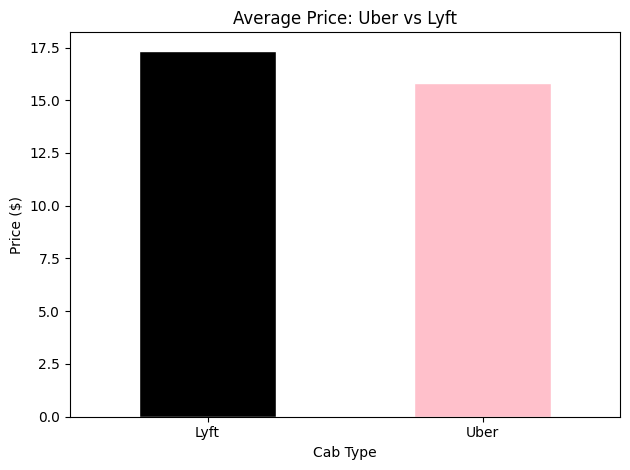

In [19]:
# Average Price: Uber vs Lyft
avg_price=ds.groupby('cab_type')['price'].mean()
print(avg_price)

avg_price.plot(kind='bar',color=['black','pink'],edgecolor='white')
plt.title("Average Price: Uber vs Lyft")
plt.ylabel("Price ($)")
plt.xlabel("Cab Type")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("avg_price_comparison.png")
plt.show()

cab_type
Lyft    9.683326
Uber    9.691718
Name: Price_per_mile, dtype: float64


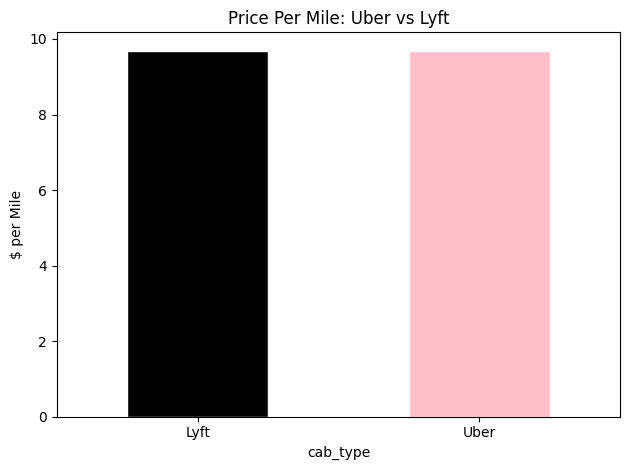

In [20]:
# Price Per Mile (Efficiency)
ds['Price_per_mile']=ds['price']/ds['distance']

ppm=ds.groupby('cab_type')['Price_per_mile'].mean()
print(ppm)

ppm.plot(kind="bar", color=["black", "pink"], edgecolor="white")
plt.title("Price Per Mile: Uber vs Lyft")
plt.ylabel("$ per Mile")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("price_per_mile.png")
plt.show()


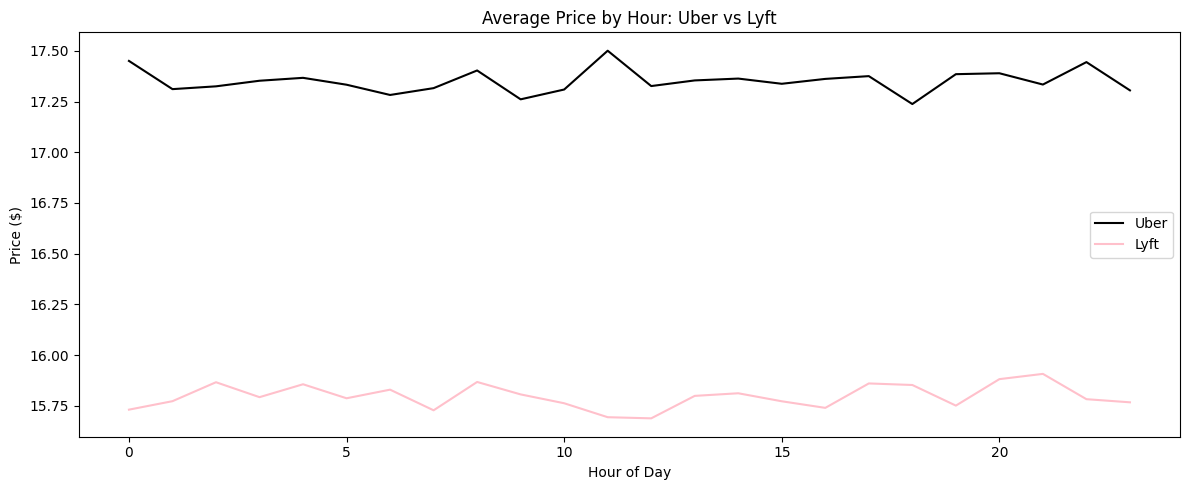

In [21]:
#Price by Hour of Day
hourly = ds.groupby(["hour", "cab_type"])["price"].mean().unstack()

hourly.plot(figsize=(12, 5), color=["black", "pink"])
plt.title("Average Price by Hour: Uber vs Lyft")
plt.ylabel("Price ($)")
plt.xlabel("Hour of Day")
plt.legend(["Uber", "Lyft"])
plt.tight_layout()
plt.savefig("price_by_hour.png")
plt.show()

cab_type
Lyft    1.03127
Uber    1.00000
Name: surge_multiplier, dtype: float64


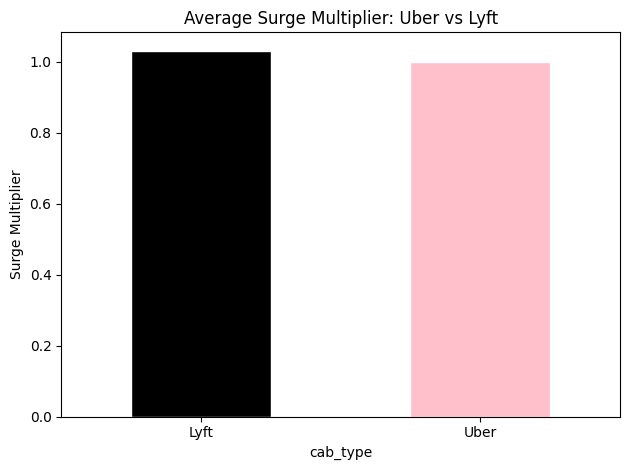

In [22]:
#Surge Multiplier Comparison
surge = ds.groupby("cab_type")["surge_multiplier"].mean()
print(surge)

surge.plot(kind="bar", color=["black", "pink"], edgecolor="white")
plt.title("Average Surge Multiplier: Uber vs Lyft")
plt.ylabel("Surge Multiplier")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("surge_comparison.png")
plt.show()


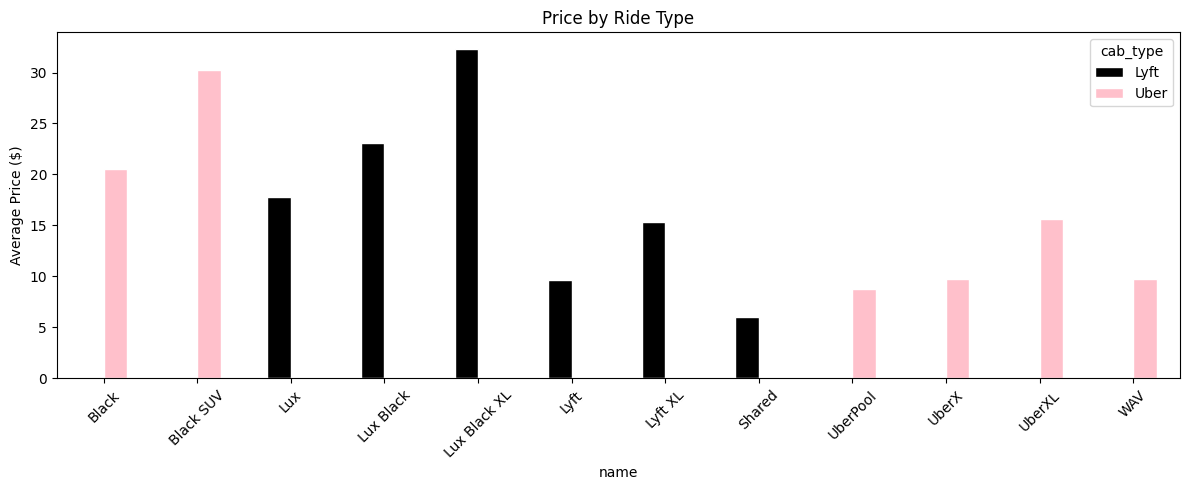

In [23]:
#Price by Ride Type
ride_price = ds.groupby(["cab_type", "name"])["price"].mean().unstack(level=0)

ride_price.plot(kind="bar", figsize=(12, 5), color=["black", "pink"], edgecolor="white")
plt.title("Price by Ride Type")
plt.ylabel("Average Price ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("price_by_ride_type.png")
plt.show()

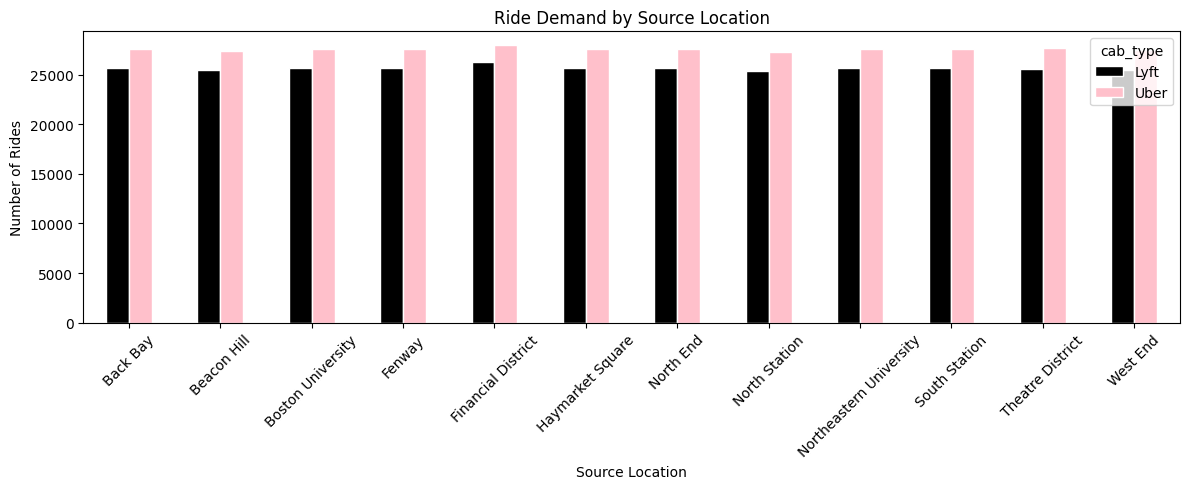

In [24]:
#Demand Clustering
#Rides Count by Source Location
# Which areas generate the most rides?
demand_by_location = ds.groupby(["source", "cab_type"]).size().unstack()

demand_by_location.plot(kind="bar", figsize=(12, 5), color=["black", "pink"], edgecolor="white")
plt.title("Ride Demand by Source Location")
plt.ylabel("Number of Rides")
plt.xlabel("Source Location")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("demand_by_location.png")
plt.show()



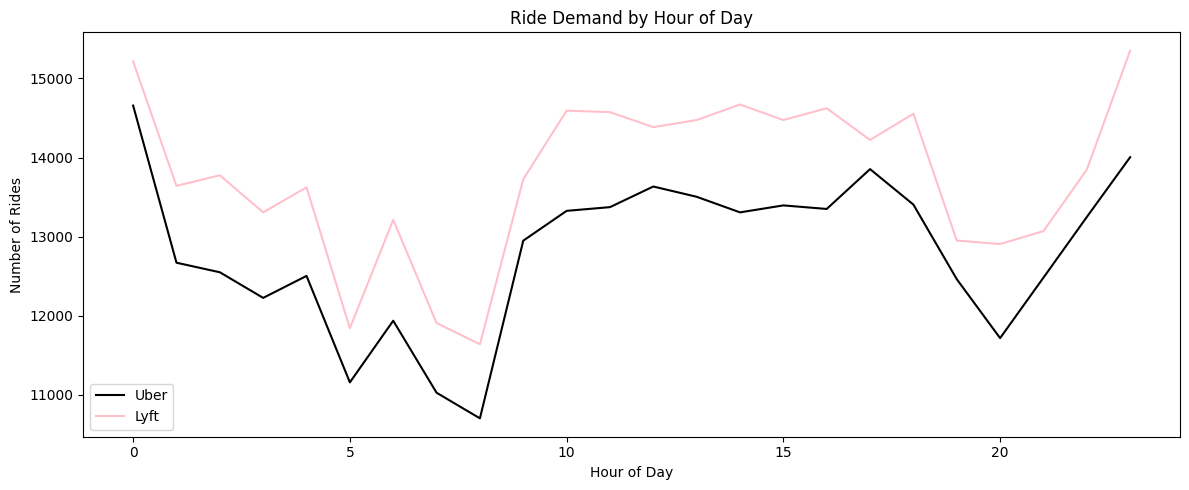

In [25]:
#Rides Count by Hour (Peak Hours)
# Which hours are busiest?
peak_hours = ds.groupby(["hour", "cab_type"]).size().unstack()

peak_hours.plot(figsize=(12, 5), color=["black", "pink"])
plt.title("Ride Demand by Hour of Day")
plt.ylabel("Number of Rides")
plt.xlabel("Hour of Day")
plt.legend(["Uber", "Lyft"])
plt.tight_layout()
plt.savefig("peak_hours.png")
plt.show()


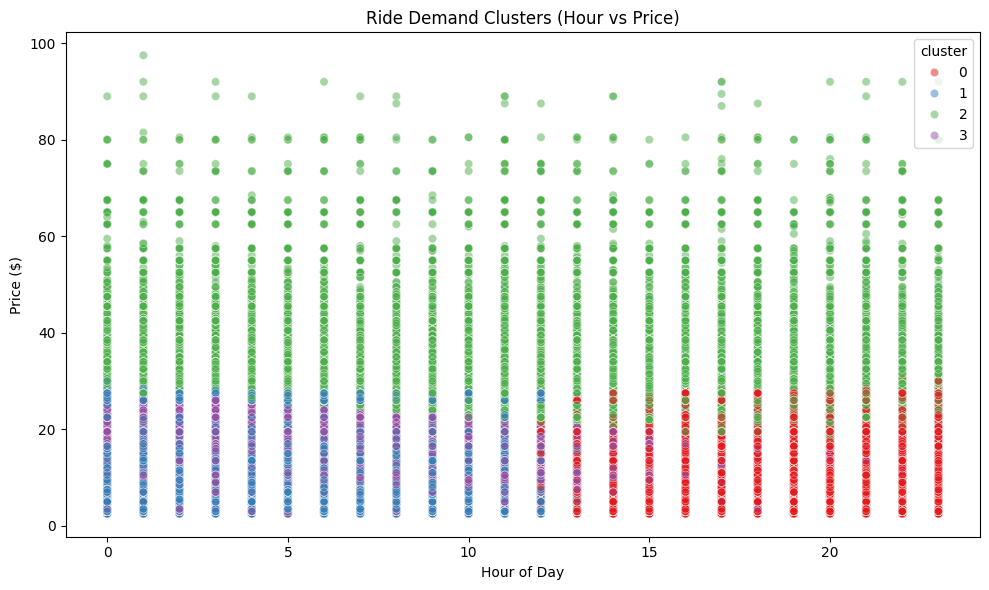

              hour      price  distance
cluster                                
0        18.273476  13.128565  1.768485
1         5.788701  13.167270  1.250638
2        12.514787  31.153980  3.175165
3         7.363496  13.857337  3.158849


In [26]:
#K-Means Clustering
# Prepare features
cluster_data = ds[["hour", "price", "distance"]].dropna()

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_data)

# Apply K-Means with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42)
cluster_data["cluster"] = kmeans.fit_predict(X_scaled)

# Plot the clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=cluster_data, x="hour", y="price", 
                hue="cluster", palette="Set1", alpha=0.5)
plt.title("Ride Demand Clusters (Hour vs Price)")
plt.xlabel("Hour of Day")
plt.ylabel("Price ($)")
plt.tight_layout()
plt.savefig("demand_clusters.png")
plt.show()

# See what each cluster looks like
print(cluster_data.groupby("cluster")[["hour", "price", "distance"]].mean())


In [27]:

# Create target column — 1 if price > average, 0 if below
avg = ds["price"].mean()
ds["expensive"] = (ds["price"] > avg).astype(int)

# Features to use
features = ["hour", "distance", "surge_multiplier"]
X = ds[features].dropna()
y = ds.loc[X.index, "expensive"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LogisticRegression()
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.6610081820746732
              precision    recall  f1-score   support

           0       0.67      0.92      0.77     80349
           1       0.61      0.23      0.33     47247

    accuracy                           0.66    127596
   macro avg       0.64      0.57      0.55    127596
weighted avg       0.65      0.66      0.61    127596



In [28]:
#Cluster Meaning (Run After k-map)
# Label clusters based on the mean values you see
cluster_summary = cluster_data.groupby("cluster")[["hour", "price", "distance"]].mean()
print(cluster_summary)


              hour      price  distance
cluster                                
0        18.273476  13.128565  1.768485
1         5.788701  13.167270  1.250638
2        12.514787  31.153980  3.175165
3         7.363496  13.857337  3.158849


In [29]:
#Combined Summary Table
# Overall summary stats side by side
summary = ds.groupby("cab_type").agg(
    Total_Rides=("price", "count"),
    Avg_Price=("price", "mean"),
    Avg_Distance=("distance", "mean"),
    Avg_Price_Per_Mile=("Price_per_mile", "mean"),
    Avg_Surge=("surge_multiplier", "mean")
).round(2)

print(summary)
summary.to_csv("uber_lyft_summary.csv")



          Total_Rides  Avg_Price  Avg_Distance  Avg_Price_Per_Mile  Avg_Surge
cab_type                                                                     
Lyft           307408      17.35          2.19                9.68       1.03
Uber           330568      15.80          2.19                9.69       1.00


In [30]:
#Most Popular Routes
# Top 5 most travelled routes for each
ds["route"] = ds["source"] + " → " + ds["destination"]

top_routes = ds.groupby(["cab_type", "route"]).size().reset_index(name="count")

uber_routes = top_routes[top_routes["cab_type"]=="Uber"].nlargest(5, "count")
lyft_routes = top_routes[top_routes["cab_type"]=="Lyft"].nlargest(5, "count")

print("Top Uber Routes:\n", uber_routes)
print("\nTop Lyft Routes:\n", lyft_routes)


Top Uber Routes:
     cab_type                               route  count
101     Uber  Financial District → South Station   4908
128     Uber  South Station → Financial District   4908
75      Uber                Back Bay → North End   4866
108     Uber                North End → Back Bay   4866
95      Uber                   Fenway → West End   4830

Top Lyft Routes:
    cab_type                               route  count
29     Lyft  Financial District → South Station   4626
56     Lyft  South Station → Financial District   4626
3      Lyft                Back Bay → North End   4548
36     Lyft                North End → Back Bay   4548
23     Lyft                   Fenway → West End   4530


In [31]:
# Cheapest Time to Ride
# Best hour to book for cheapest ride
cheapest_hour = ds.groupby(["cab_type", "hour"])["price"].mean().reset_index()

uber_cheap = cheapest_hour[cheapest_hour["cab_type"]=="Uber"].nsmallest(3, "price")
lyft_cheap = cheapest_hour[cheapest_hour["cab_type"]=="Lyft"].nsmallest(3, "price")

print("Cheapest hours for Uber:\n", uber_cheap)
print("\nCheapest hours for Lyft:\n", lyft_cheap)


Cheapest hours for Uber:
    cab_type  hour      price
36     Uber    12  15.688786
35     Uber    11  15.694353
31     Uber     7  15.728372

Cheapest hours for Lyft:
    cab_type  hour      price
18     Lyft    18  17.237541
9      Lyft     9  17.260774
6      Lyft     6  17.282279


In [32]:
#Most Expensive Time to Ride
uber_exp = cheapest_hour[cheapest_hour["cab_type"]=="Uber"].nlargest(3, "price")
lyft_exp = cheapest_hour[cheapest_hour["cab_type"]=="Lyft"].nlargest(3, "price")

print("Most expensive hours for Uber:\n", uber_exp)
print("\nMost expensive hours for Lyft:\n", lyft_exp)


Most expensive hours for Uber:
    cab_type  hour      price
45     Uber    21  15.907874
44     Uber    20  15.881984
32     Uber     8  15.868050

Most expensive hours for Lyft:
    cab_type  hour      price
11     Lyft    11  17.500337
0      Lyft     0  17.450058
22     Lyft    22  17.444252
